# 🚚 Logistics Query Tool — Route Cost & Saturation Analysis

**Author:** Giuseppe Iaccarino  
**Date:** 2022 — Revised 2026  
**Context:** Interactive analysis tool built on top of SIGEP transport planning exports from a central distribution warehouse.  
Covers outbound deliveries to retail PDV (points of sale) across Tuscany, Umbria and Lazio.

---

### What this tool does

| Function | Usage | Output |
|---|---|---|
| `QueryViaggio(route)` | `QueryViaggio('FI - GV FIRENZE')` | PDV list, delivery frequency, weekday distribution |
| `VisualGite(prov)` | `VisualGite('AR')` or `VisualGite('AR','SI')` | Saturation & cost charts + full KPI table per route |

### KPIs computed
- **Saturazione** — vehicle load / capacity × 100 (target: > 70%)
- **Costo_Viaggio** — km × rate by vehicle category (€/km)
- **Costo_per_Collo** — trip cost / cases delivered (key efficiency indicator)
- **Colli/KM** — cases per km traveled

---
*Data anonymized for public sharing. All PDV names replaced with codes.*

## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import glob
import os
from IPython.display import display

# ── Visual style ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Paths ──────────────────────────────────────────────────────
PATH_SIGEP  = 'PIANSIGSIE*.xls'   # input glob pattern
PATH_PYTHON = './PYTHON/'
PATH_EXCEL  = './EXCEL/'
os.makedirs(PATH_PYTHON, exist_ok=True)
os.makedirs(PATH_EXCEL,  exist_ok=True)

# ── Vehicle rate table (€/km) ──────────────────────────────────
TARIFFE = {
    '15 - MOTRICE 3 ASSI':            1.048,
    '10 - MOTRICE 2 ASSI':            0.993,
    '11 - MOTRICE 2 ASSI - SPECIALE': 0.993,
    '5 - DAILY':                      0.993,
    '30 - BILICO':                    1.248,
    '20 - BILICHETTO':                1.248,
}

# ── Columns to load from SIGEP ─────────────────────────────────
USECOLS = [
    'PARTENZA', 'N_VIAGGIO', 'DATA_VIAGGIO', 'PDV', 'RAGIONE_SOCIALE',
    'LOCALITA', 'PROVINCIA', 'KM', 'MERCEOLOGIA', 'COLLI',
    'UNITA_CARICO_EQ', 'UNITA_CARICO_MEZZO', 'DESCRIZIONE',
    'CATEGORIA', 'NOTE_VIAGGIO', 'VIAGGIO_AGENDA',
]

# ── Special trips to exclude from saturation analysis ──────────
# (navettaggio, vuoti, transit point, taxi merci distort averages)
EXCLUDE_PATTERNS = [
    'TX - TAXI MERCI',
    'SI - FR SAPORI DI TOSCANA',
    'X - VUOTI GRIFOGEL',
    'TP2 - TRANSIT POINT MON',
    'TP1 - TRANSIT POINT BAD',
    'AR - GV AMBRA',
]
# Also exclude any route starting with X- or TP
EXCLUDE_PREFIXES = ('^X\\s*-', '^TP')

print('Configuration loaded ✓')

Configuration loaded ✓


## 2. Load & Prepare Data

In [2]:
# ── Load all SIGEP Excel files ─────────────────────────────────
files = glob.glob(PATH_SIGEP)
if not files:
    raise FileNotFoundError(f'No files matching {PATH_SIGEP} found in current directory.')
print(f'Found {len(files)} SIGEP file(s): {files}')

raw = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)
raw.to_csv(PATH_PYTHON + 'dataframe.csv', sep=';', encoding='ISO-8859-1', index=False)

# ── Read with typed columns ────────────────────────────────────
data = pd.read_csv(
    PATH_PYTHON + 'dataframe.csv',
    delimiter=';', encoding='ISO-8859-1',
    usecols=USECOLS,
    dtype={'N_VIAGGIO': int, 'VIAGGIO_AGENDA': int,
           'COLLI': float, 'UNITA_CARICO_MEZZO': float},
)

# ── Clean: zeros → NaN, dash placeholders → NaN ───────────────
# NOTE: only numeric zeros are missing data; do NOT replace 0 in
# integer keys like N_VIAGGIO or PDV.
num_cols = ['KM', 'COLLI', 'UNITA_CARICO_EQ', 'UNITA_CARICO_MEZZO']
for col in num_cols:
    data[col] = data[col].replace(0, np.nan).replace(0.0, np.nan)
data.replace('-', np.nan, inplace=True)

# ── Date & weekday ────────────────────────────────────────────
data['DATA_VIAGGIO'] = pd.to_datetime(data['DATA_VIAGGIO'], format='%d/%m/%Y')

# day_name(locale='Italian') fails on macOS/Python 3.14 — map manually instead
_GIORNI = {
    'Monday': 'Lunedì', 'Tuesday': 'Martedì', 'Wednesday': 'Mercoledì',
    'Thursday': 'Giovedì', 'Friday': 'Venerdì', 'Saturday': 'Sabato', 'Sunday': 'Domenica'
}
data['GIORNO_WK'] = data['DATA_VIAGGIO'].dt.day_name().map(_GIORNI)

# ── Derived columns ───────────────────────────────────────────
data['SAT_PARZIALE'] = data['UNITA_CARICO_EQ'] / data['UNITA_CARICO_MEZZO']

# Route group: strip trailing numbers (e.g. 'FI - GV FIRENZE 3' → 'FI - GV FIRENZE')
data['VIAGGIO_GRP'] = data['NOTE_VIAGGIO'].str.extract(r'(.*\S\D\D)')
data['VIAGGIO_GRP'] = data['VIAGGIO_GRP'].str.strip()  # fix: remove spurious spaces from SIGEP export

# Vehicle rate from config dict (avoids long chained if/else)
data['TARIFFA_KM'] = data['CATEGORIA'].map(TARIFFE).astype(float)

# ── Anonymize PDV for public sharing ─────────────────────────
pdv_map = {name: f'PDV_{i:05d}'
           for i, name in enumerate(sorted(data['RAGIONE_SOCIALE'].dropna().unique()))}
data['PDV_ID'] = data['RAGIONE_SOCIALE'].map(pdv_map)

# ── Reorder columns ───────────────────────────────────────────
data = data.reindex(columns=[
    'PARTENZA', 'N_VIAGGIO', 'DATA_VIAGGIO', 'GIORNO_WK', 'PDV', 'PDV_ID',
    'RAGIONE_SOCIALE', 'LOCALITA', 'PROVINCIA', 'KM', 'MERCEOLOGIA',
    'COLLI', 'UNITA_CARICO_EQ', 'UNITA_CARICO_MEZZO', 'SAT_PARZIALE',
    'DESCRIZIONE', 'CATEGORIA', 'TARIFFA_KM',
    'NOTE_VIAGGIO', 'VIAGGIO_AGENDA', 'VIAGGIO_GRP',
])

data.to_csv(PATH_EXCEL + 'DFperEXCEL.csv', sep=';', encoding='ISO-8859-1', index=False)

print(f'Data loaded: {len(data):,} rows  |  '
      f'{data["N_VIAGGIO"].nunique():,} trips  |  '
      f'{data["PDV"].nunique():,} PDVs  |  '
      f'{data["PROVINCIA"].nunique()} provinces')
print(f'Date range: {data["DATA_VIAGGIO"].min().date()} → {data["DATA_VIAGGIO"].max().date()}')

Found 15 SIGEP file(s): ['PIANSIGSIE_62656_MAGGIO2022.xls', 'PIANSIGSIE_58653_20220328165318.xls', 'PIANSIGSIE_64062_GIUGNO2022.xls', 'PIANSIGSIE_66703_LUGLIO2022.xls', 'PIANSIGSIE_60399_20220426153339.xls', 'PIANSIGSIE_69853_AGOSTO2022.xls', 'PIANSIGSIE_57618_GENNAIO2022.xls', 'PIANSIGSIE_64062_20220708162443.xls', 'PIANSIGSIE_66703_20220816135024.xls', 'PIANSIGSIE_60908_APRILE2022.xls', 'PIANSIGSIE_58653_FEBBRAIO2022.xls', 'PIANSIGSIE_60399_MARZO2022.xls', 'PIANSIGSIE_60908_20220509100729.xls', 'PIANSIGSIE_57618_20220314111541.xls', 'PIANSIGSIE_62656_20220616121737.xls']
Data loaded: 186,603 rows  |  19,919 trips  |  580 PDVs  |  18 provinces
Date range: 2022-01-01 → 2022-08-31


## 3. Build Trip-Level Summary Table

In [3]:
def _first(series):
    """Return first non-null value of a series."""
    v = series.dropna()
    return v.iloc[0] if len(v) else np.nan


def build_trip_table(data: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates raw SIGEP rows to one row per trip (N_VIAGGIO).

    Computes:
      Costo_Viaggio   = km × tariffa
      Colli           = sum of all cases on the trip
      Costo_per_Collo = trip cost / total cases  (NaN if Colli == 0)
      Saturazione     = loaded units / vehicle capacity × 100

    Drops trips where Saturazione > 100 (data quality issue).
    """
    grp = data.groupby('N_VIAGGIO', sort=False)

    table = pd.DataFrame({
        'Viaggio':   grp['N_VIAGGIO'].first(),
        'Gita':      grp['VIAGGIO_GRP'].first(),
        'Giorno':    grp['GIORNO_WK'].first(),
        'Provincia': grp['PROVINCIA'].first(),
        'Mezzo':     grp['CATEGORIA'].first(),
        'Tariffa':   grp['TARIFFA_KM'].first(),
        'KM':        grp['KM'].first(),
        'Colli':     grp['COLLI'].sum(min_count=1),
        'Caricato':  grp['UNITA_CARICO_EQ'].sum(min_count=1),
        'Capienza':  grp['UNITA_CARICO_MEZZO'].first(),
    }).reset_index(drop=True)

    table['Costo_Viaggio'] = (table['Tariffa'] * table['KM']).round(2)

    # FIX: avoid inf — only divide when Colli > 0
    table['Costo_per_Collo'] = np.where(
        table['Colli'] > 0,
        (table['Costo_Viaggio'] / table['Colli']).round(2),
        np.nan
    )
    table['Colli_KM'] = np.where(
        table['KM'] > 0,
        (table['Colli'] / table['KM']).round(4),
        np.nan
    )
    table['Saturazione'] = np.where(
        table['Capienza'] > 0,
        (table['Caricato'] / table['Capienza'] * 100).round(2),
        np.nan
    )

    # Drop data-quality rows (over-saturated)
    table = table[table['Saturazione'].isna() | (table['Saturazione'] <= 100)].copy()
    table = table.sort_values('Saturazione', ascending=False).reset_index(drop=True)

    return table


table = build_trip_table(data)

# Exclude special trip types from saturation/cost analysis
mask_exact  = table['Gita'].isin(EXCLUDE_PATTERNS)
mask_prefix = table['Gita'].str.contains('|'.join(EXCLUDE_PREFIXES), regex=True, na=False)
table_clean = table[~(mask_exact | mask_prefix)].copy().reset_index(drop=True)

table.to_csv(PATH_EXCEL + 'TABLEperEXCEL.csv', sep=';', encoding='ISO-8859-1', index=False)

print(f'Trip table: {len(table):,} trips total  |  {len(table_clean):,} after excluding special routes')
print(f'Routes excluded: {mask_exact.sum() + mask_prefix.sum()}')
display(table_clean.head(5))

Trip table: 9,188 trips total  |  7,473 after excluding special routes
Routes excluded: 1737


,Viaggio,Gita,Giorno,Provincia,Mezzo,Tariffa,KM,Colli,Caricato,Capienza,Costo_Viaggio,Costo_per_Collo,Colli_KM,Saturazione
0,543212,GR - GV FOLLONICA,Mercoledì,LI,10 - MOTRICE 2 ASSI,0.99,321.00,996.00,26.00,26.00,318.75,0.32,3.10,100.00
1,598182,GR - GV PORTO SANTO STEFANO,Martedì,GR,30 - BILICO 54 ROLL,NaN,256.00,4141.00,54.00,54.00,NaN,NaN,16.18,100.00
2,551686,LU - FR VERSILIA,Venerdì,LU,15 - MOTRICE 3 ASSI,1.05,306.00,1332.00,36.00,36.00,320.69,0.24,4.35,100.00
3,506173,SI - GV COLLE VAL D'ELSA,Venerdì,SI,5 - DAILY,0.99,14.00,388.00,14.00,14.00,13.90,0.04,27.71,100.00
4,477728,LI - OF PIOMBINO,Mercoledì,GR,10 - MOTRICE 2 ASSI,0.99,393.00,482.00,26.00,26.00,390.25,0.81,1.23,100.00


## 4. Query Functions

In [4]:
WEEK_ORDER = ['Lunedì', 'Martedì', 'Mercoledì', 'Giovedì', 'Venerdì', 'Sabato']
COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#00BCD4']


def QueryViaggio(viaggio: str) -> pd.DataFrame:
    """
    Analyzes a specific route group (VIAGGIO_GRP).

    Parameters
    ----------
    viaggio : str
        Route name as it appears in NOTE_VIAGGIO (without trailing number).
        Example: 'FI - GV FIRENZE'

    Returns
    -------
    DataFrame with one row per PDV served on that route,
    sorted by delivery frequency.
    """
    subset = data[data['VIAGGIO_GRP'] == viaggio].copy()
    if subset.empty:
        print(f'[!] Route "{viaggio}" not found. Check spelling.')
        print('Available routes sample:', data['VIAGGIO_GRP'].dropna().unique()[:10].tolist())
        return pd.DataFrame()

    frequency = len(subset)

    # ── Per-PDV aggregation ───────────────────────────────────
    pdv_grp = subset.groupby('PDV', sort=False)
    result = pd.DataFrame({
        'Codice_PDV':      pdv_grp['PDV'].first(),
        'PDV_ID':          pdv_grp['PDV_ID'].first(),
        'Provincia':       pdv_grp['PROVINCIA'].first(),
        'N_Consegne':      pdv_grp['N_VIAGGIO'].count(),
        'Giorni_Consegna': pdv_grp['GIORNO_WK'].apply(
                               lambda s: s.value_counts(normalize=True).index.tolist()),
    }).reset_index(drop=True).sort_values('N_Consegne', ascending=False).reset_index(drop=True)

    # ── Plot 1: PDV frequency ─────────────────────────────────
    n = len(result)
    fig, ax = plt.subplots(figsize=(max(12, n * 0.4), 6))
    bars = ax.bar(result['PDV_ID'], result['N_Consegne'],
                  color='#2196F3', alpha=0.85, edgecolor='white')
    ax.set_title(f'Route: {viaggio}  —  {frequency} trips recorded',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Point of Sale (anonymized)', fontsize=12)
    ax.set_ylabel('Delivery frequency', fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    # Annotate top 5
    for bar, val in zip(bars[:5], result['N_Consegne'][:5]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PATH_PYTHON + f'query_{viaggio.replace(" ","_").replace("/","-")}_pdv.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    # ── Plot 2: weekday distribution ──────────────────────────
    day_counts = subset['GIORNO_WK'].value_counts(normalize=True).reindex(WEEK_ORDER, fill_value=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(day_counts.index, day_counts.values * 100,
           color='#FF9800', alpha=0.85, edgecolor='white')
    ax.set_title(f'Delivery day distribution — {viaggio}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of week', fontsize=11)
    ax.set_ylabel('% of deliveries', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(PATH_PYTHON + f'query_{viaggio.replace(" ","_").replace("/","-")}_days.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    print(f'Route "{viaggio}" → {frequency} trips | {len(result)} unique PDVs served')
    display(result)
    return result


def VisualGite(*provinces) -> pd.DataFrame:
    """
    Analyzes and visualizes all routes serving the given province(s).

    Parameters
    ----------
    *provinces : str
        One or more province codes (e.g. 'AR', 'SI', 'FI').
        Pass multiple to compare: VisualGite('AR', 'SI')

    Returns
    -------
    DataFrame with one row per route, aggregated KPIs.
    """
    provinces = [p for p in provinces if pd.notna(p)]
    subset = table_clean[table_clean['Provincia'].isin(provinces)].copy()
    if subset.empty:
        print(f'[!] No data for provinces: {provinces}')
        return pd.DataFrame()

    gite = subset['Gita'].dropna().unique()

    # ── Aggregate per route ───────────────────────────────────
    def _agg(gita_name):
        g = subset[subset['Gita'] == gita_name]
        giorno_mode = g['Giorno'].mode()
        prov_mode   = g['Provincia'].mode()
        return {
            'Gita':              gita_name,
            'Frequenza':         len(g),
            'Giorno_Principale': giorno_mode.iloc[0] if len(giorno_mode) else np.nan,
            'Provincia':         prov_mode.iloc[0]   if len(prov_mode)   else np.nan,
            'Tariffa_AVG':       g['Tariffa'].mean(),
            'KM_AVG':            g['KM'].mean(),
            'Costo_Viaggio_AVG': g['Costo_Viaggio'].mean(),
            'Colli_AVG':         g['Colli'].mean(),
            # FIX: mean only of finite values — avoids inf propagation
            'Costo_per_Collo_AVG': g['Costo_per_Collo'].replace([np.inf, -np.inf], np.nan).mean(),
            'Colli_KM_AVG':      g['Colli_KM'].replace([np.inf, -np.inf], np.nan).mean(),
            'Saturazione_AVG':   g['Saturazione'].mean(),
        }

    newtable = pd.DataFrame([_agg(g) for g in gite])
    newtable = newtable.sort_values('Frequenza', ascending=False).reset_index(drop=True)
    newtable = newtable.round(2)

    prov_label = ' + '.join(provinces)

    # ── Plot 1: Saturation by route (sorted by frequency) ─────
    SAT_TARGET = 70
    fig, ax = plt.subplots(figsize=(max(14, len(newtable) * 0.45), 7))
    colors = ['#EF5350' if v < SAT_TARGET else '#4CAF50'
              for v in newtable['Saturazione_AVG'].fillna(0)]
    ax.bar(range(len(newtable)), newtable['Saturazione_AVG'],
           color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(SAT_TARGET, color='black', linestyle='--', linewidth=1.2,
               label=f'Target {SAT_TARGET}%')
    ax.set_xticks(range(len(newtable)))
    ax.set_xticklabels(newtable['Gita'], rotation=90, fontsize=9)
    ax.set_title(f'Average Vehicle Saturation by Route — Province: {prov_label}\n'
                 f'(green = above target, red = below target)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Avg Saturation (%)', fontsize=11)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(PATH_PYTHON + f'visual_{prov_label}_saturazione.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    # ── Plot 2: Avg trip cost by route ────────────────────────
    sorted_cost = newtable.sort_values('Costo_Viaggio_AVG', ascending=False)
    fig, ax = plt.subplots(figsize=(max(14, len(newtable) * 0.45), 5))
    ax.bar(range(len(sorted_cost)), sorted_cost['Costo_Viaggio_AVG'],
           color='#5C6BC0', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(sorted_cost)))
    ax.set_xticklabels(sorted_cost['Gita'], rotation=90, fontsize=9)
    ax.set_title(f'Average Trip Cost (€) by Route — Province: {prov_label}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Avg Cost (€)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(PATH_PYTHON + f'visual_{prov_label}_costo.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    # ── Plot 3: Cost per case (efficiency scatter) ────────────
    fig, ax = plt.subplots(figsize=(max(14, len(newtable) * 0.45), 5))
    sc = ax.scatter(
        newtable['Saturazione_AVG'],
        newtable['Costo_per_Collo_AVG'],
        s=newtable['Frequenza'] * 3,
        c=newtable['Frequenza'],
        cmap='YlOrRd', alpha=0.8, edgecolors='grey', linewidth=0.5
    )
    plt.colorbar(sc, ax=ax, label='Route frequency (n trips)')
    ax.axvline(SAT_TARGET, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'Cost per Case vs. Saturation — Province: {prov_label}\n'
                 f'(bubble size = route frequency)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Avg Saturation (%)', fontsize=11)
    ax.set_ylabel('Avg Cost per Case (€)', fontsize=11)
    # Annotate outliers (high cost per case)
    threshold = newtable['Costo_per_Collo_AVG'].quantile(0.85)
    for _, row in newtable[newtable['Costo_per_Collo_AVG'] > threshold].iterrows():
        ax.annotate(row['Gita'][:20],
                    xy=(row['Saturazione_AVG'], row['Costo_per_Collo_AVG']),
                    xytext=(5, 5), textcoords='offset points', fontsize=7)
    plt.tight_layout()
    plt.savefig(PATH_PYTHON + f'visual_{prov_label}_scatter.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    display(newtable)
    return newtable




def GiteWeek(*provinces) -> pd.DataFrame:
    """
    Weekly schedule view for a province (or combination of provinces).
    Shows all routes active on each day of the week with their KPIs.

    Useful to identify which days are overcrowded or underloaded,
    and to spot consolidation opportunities within a scheduling week.

    Parameters
    ----------
    *provinces : str
        One or more province codes (e.g. 'MS', 'SP').
        Pass multiple to combine: GiteWeek('MS', 'SP')

    Returns
    -------
    DataFrame with one row per (day, route) combination,
    including frequency, avg cost, avg colli, avg saturation.
    """
    provinces = [p for p in provinces if pd.notna(p)]
    subset = table_clean[table_clean['Provincia'].isin(provinces)].copy()
    if subset.empty:
        print(f'[!] No data for provinces: {provinces}')
        return pd.DataFrame()

    prov_label = ' + '.join(provinces)
    rows = []

    for day in WEEK_ORDER:
        day_sub = subset[subset['Giorno'] == day]
        if day_sub.empty:
            continue
        for gita in day_sub['Gita'].dropna().unique():
            g = day_sub[day_sub['Gita'] == gita]
            rows.append({
                'Giorno':              day,
                'Gita':                gita,
                'N_Viaggi':            len(g),
                'KM_AVG':              round(g['KM'].mean(), 1),
                'Costo_Viaggio_AVG':   round(g['Costo_Viaggio'].mean(), 2),
                'Colli_AVG':           round(g['Colli'].mean(), 1),
                'Costo_per_Collo_AVG': round(
                    g['Costo_per_Collo'].replace([np.inf, -np.inf], np.nan).mean(), 2),
                'Saturazione_AVG':     round(g['Saturazione'].mean(), 1),
            })

    if not rows:
        print(f'[!] No weekly data found for {prov_label}')
        return pd.DataFrame()

    result = pd.DataFrame(rows)

    # ── Plot 1: route count per day (how busy is each day?) ───
    day_counts = result.groupby('Giorno')['Gita'].count().reindex(WEEK_ORDER, fill_value=0)
    sat_by_day = result.groupby('Giorno')['Saturazione_AVG'].mean().reindex(WEEK_ORDER)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Weekly Schedule Overview — Province: {prov_label}',
                 fontsize=13, fontweight='bold')

    axes[0].bar(day_counts.index, day_counts.values,
                color='#5C6BC0', alpha=0.85, edgecolor='white')
    axes[0].set_title('Active routes per day', fontweight='bold')
    axes[0].set_ylabel('Number of routes')
    for i, (day, val) in enumerate(day_counts.items()):
        if val > 0:
            axes[0].text(i, val + 0.1, str(val), ha='center', fontsize=10, fontweight='bold')

    colors_sat = ['#EF5350' if pd.isna(v) or v < 70 else '#4CAF50'
                  for v in sat_by_day.values]
    axes[1].bar(sat_by_day.index, sat_by_day.values,
                color=colors_sat, alpha=0.85, edgecolor='white')
    axes[1].axhline(70, color='black', linestyle='--', linewidth=1.2, label='Target 70%')
    axes[1].set_title('Avg saturation by day', fontweight='bold')
    axes[1].set_ylabel('Avg Saturation (%)')
    axes[1].legend(fontsize=9)
    for i, (day, val) in enumerate(sat_by_day.items()):
        if pd.notna(val):
            axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(PATH_PYTHON + f'giteweek_{prov_label}_overview.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    # ── Plot 2: heatmap — saturation by day × route ────────────
    pivot = result.pivot_table(
        index='Gita', columns='Giorno', values='Saturazione_AVG'
    ).reindex(columns=[d for d in WEEK_ORDER if d in result['Giorno'].values])
    pivot = pivot.dropna(how='all').sort_values(
        by=pivot.columns.tolist(), ascending=False, na_position='last'
    )

    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 1.5),
                                        max(6,  len(pivot) * 0.35)))
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                       vmin=0, vmax=100)
        plt.colorbar(im, ax=ax, label='Avg Saturation (%)', shrink=0.6)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=10)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_title(
            f'Saturation Heatmap: Day × Route — {prov_label}\n'
            f'(green = high saturation, red = low)',
            fontsize=12, fontweight='bold'
        )
        # Annotate cells
        for r in range(len(pivot.index)):
            for c in range(len(pivot.columns)):
                val = pivot.values[r, c]
                if not np.isnan(val):
                    ax.text(c, r, f'{val:.0f}%', ha='center', va='center',
                            fontsize=7, color='black' if 30 < val < 80 else 'white')
        plt.tight_layout()
        plt.savefig(PATH_PYTHON + f'giteweek_{prov_label}_heatmap.png',
                    bbox_inches='tight', dpi=150)
        plt.show()

    display(result.sort_values(['Giorno', 'Saturazione_AVG'], ascending=[True, False]))
    print(f'\nProvince: {prov_label} | Days with routes: {result["Giorno"].nunique()} | '
          f'Unique routes: {result["Gita"].nunique()}')
    return result


print('Functions QueryViaggio(), VisualGite() and GiteWeek() ready ✓')

Functions QueryViaggio(), VisualGite() and GiteWeek() ready ✓


## 5. Example Queries

> Run these cells as-is, or replace with any route/province available in your data.

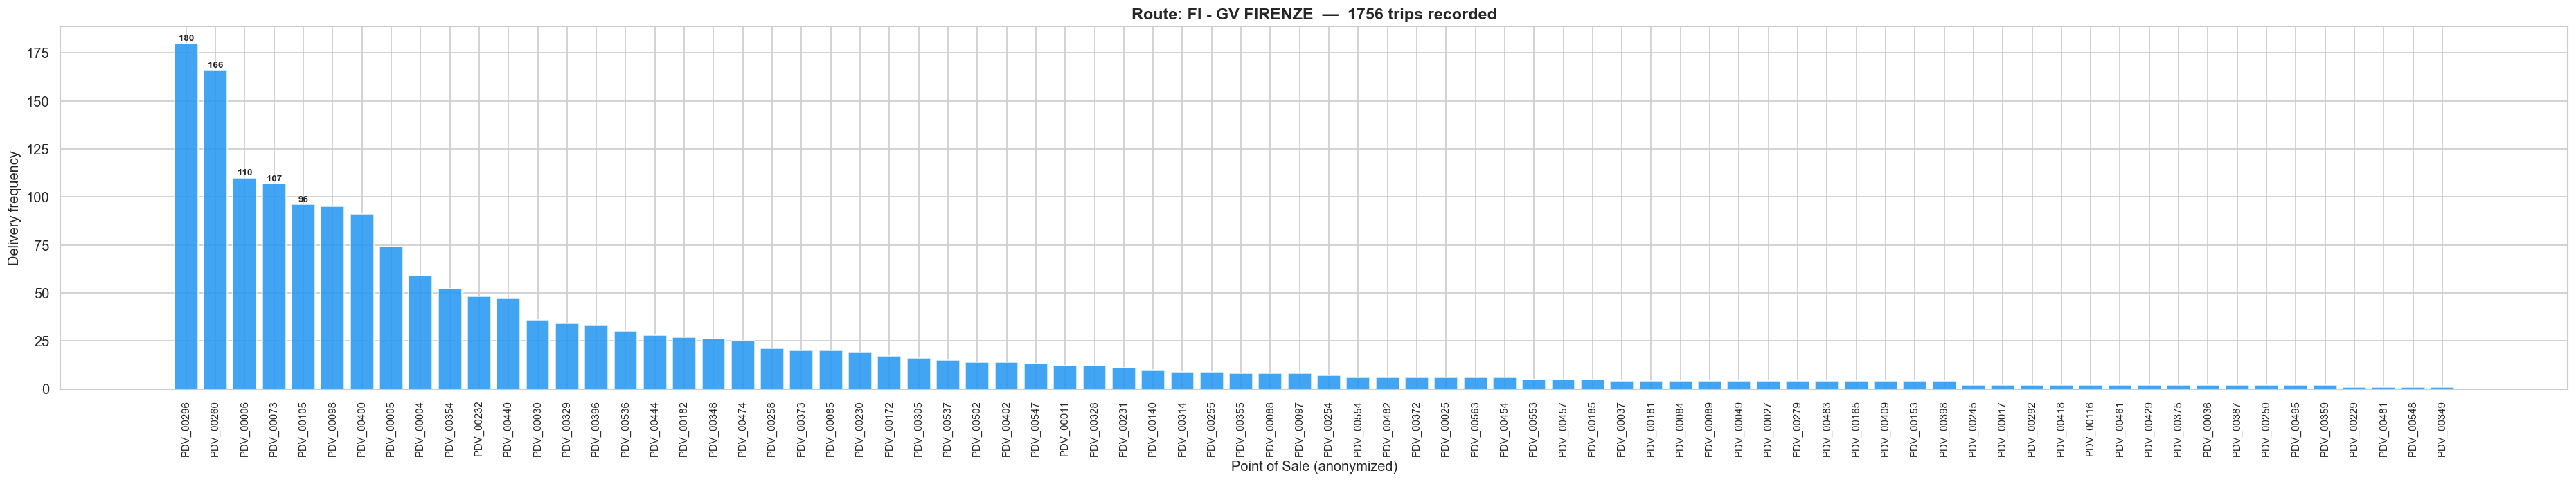

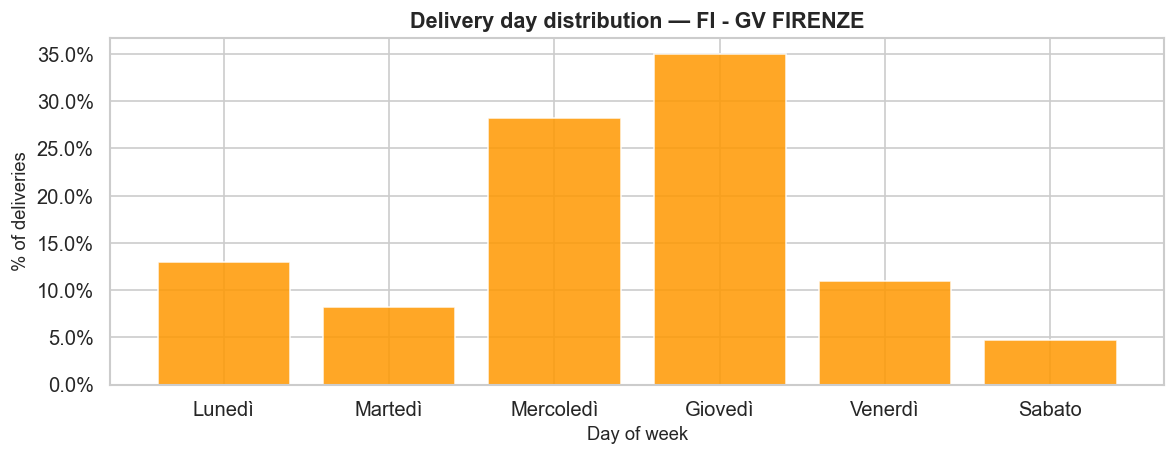

Route "FI - GV FIRENZE" → 1756 trips | 78 unique PDVs served


,Codice_PDV,PDV_ID,Provincia,N_Consegne,Giorni_Consegna
0,70562,PDV_00296,FI,180,"[Giovedì, Lunedì, Venerdì]"
1,70517,PDV_00260,FI,166,"[Mercoledì, Venerdì, Lunedì]"
2,38792,PDV_00006,FI,110,"[Sabato, Martedì, Giovedì, Venerdì, Lunedì, Do..."
3,38460,PDV_00073,FI,107,"[Mercoledì, Giovedì]"
4,70568,PDV_00105,FI,96,"[Giovedì, Venerdì]"
...,...,...,...,...,...
73,38510,PDV_00359,AR,2,[Giovedì]
74,1775,PDV_00229,FI,1,[Mercoledì]
75,20697,PDV_00481,FI,1,[Mercoledì]
76,38704,PDV_00548,PT,1,[Giovedì]


In [5]:
# ── Query a specific route ─────────────────────────────────────
result_fi = QueryViaggio('FI - GV FIRENZE')

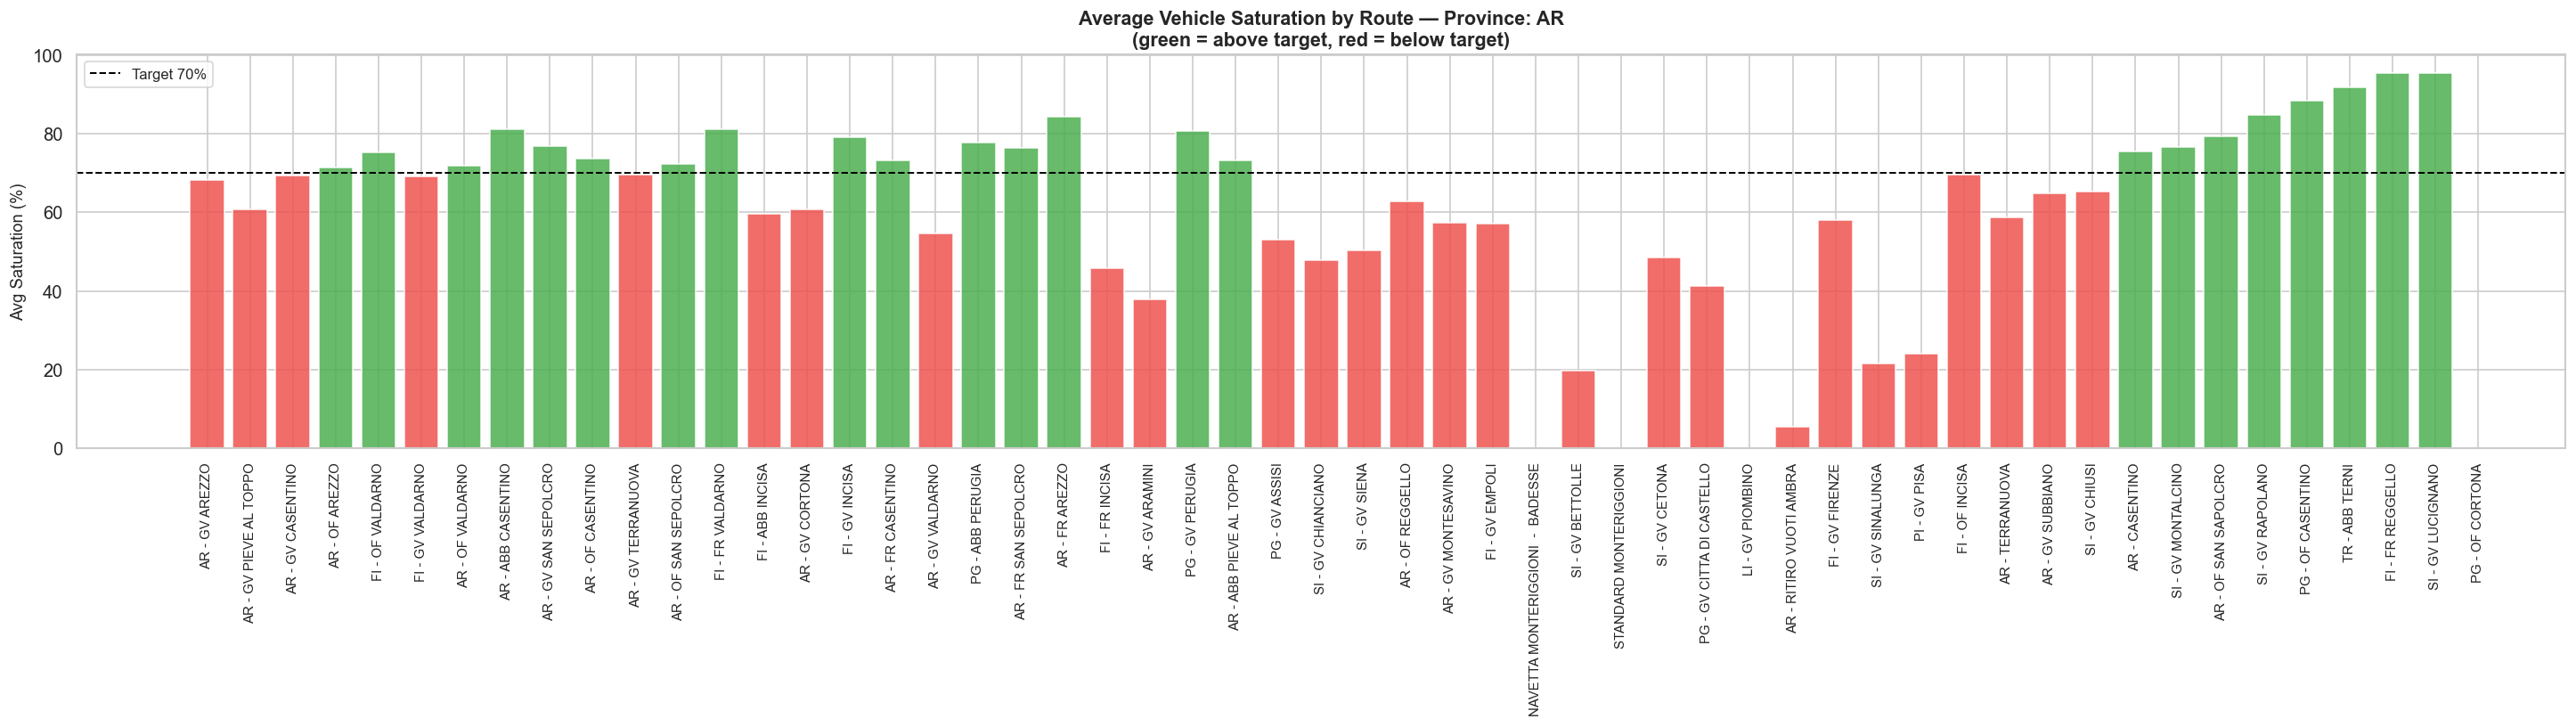

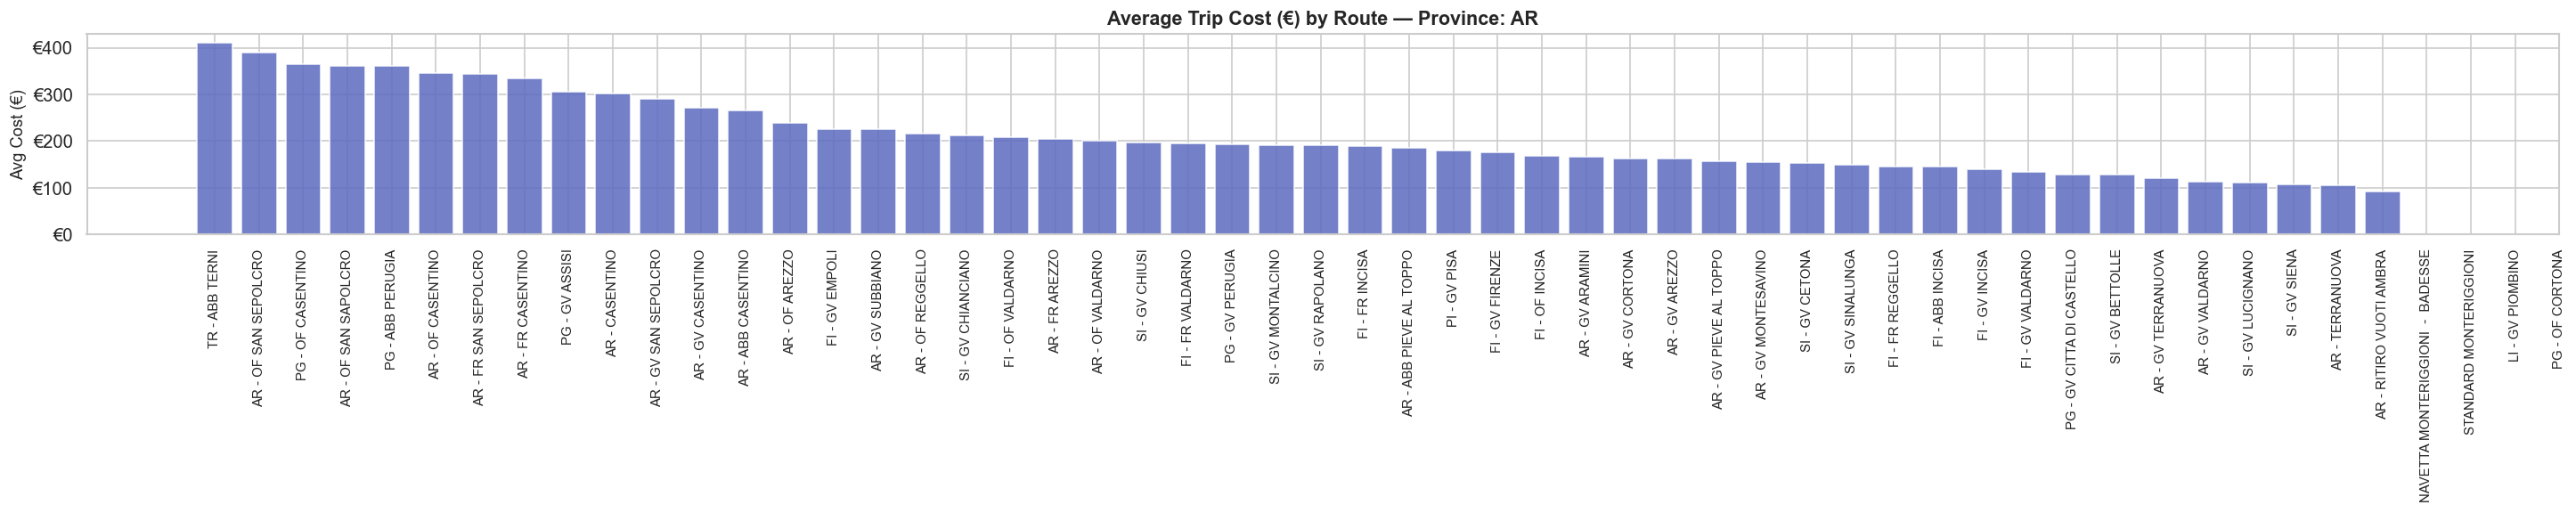

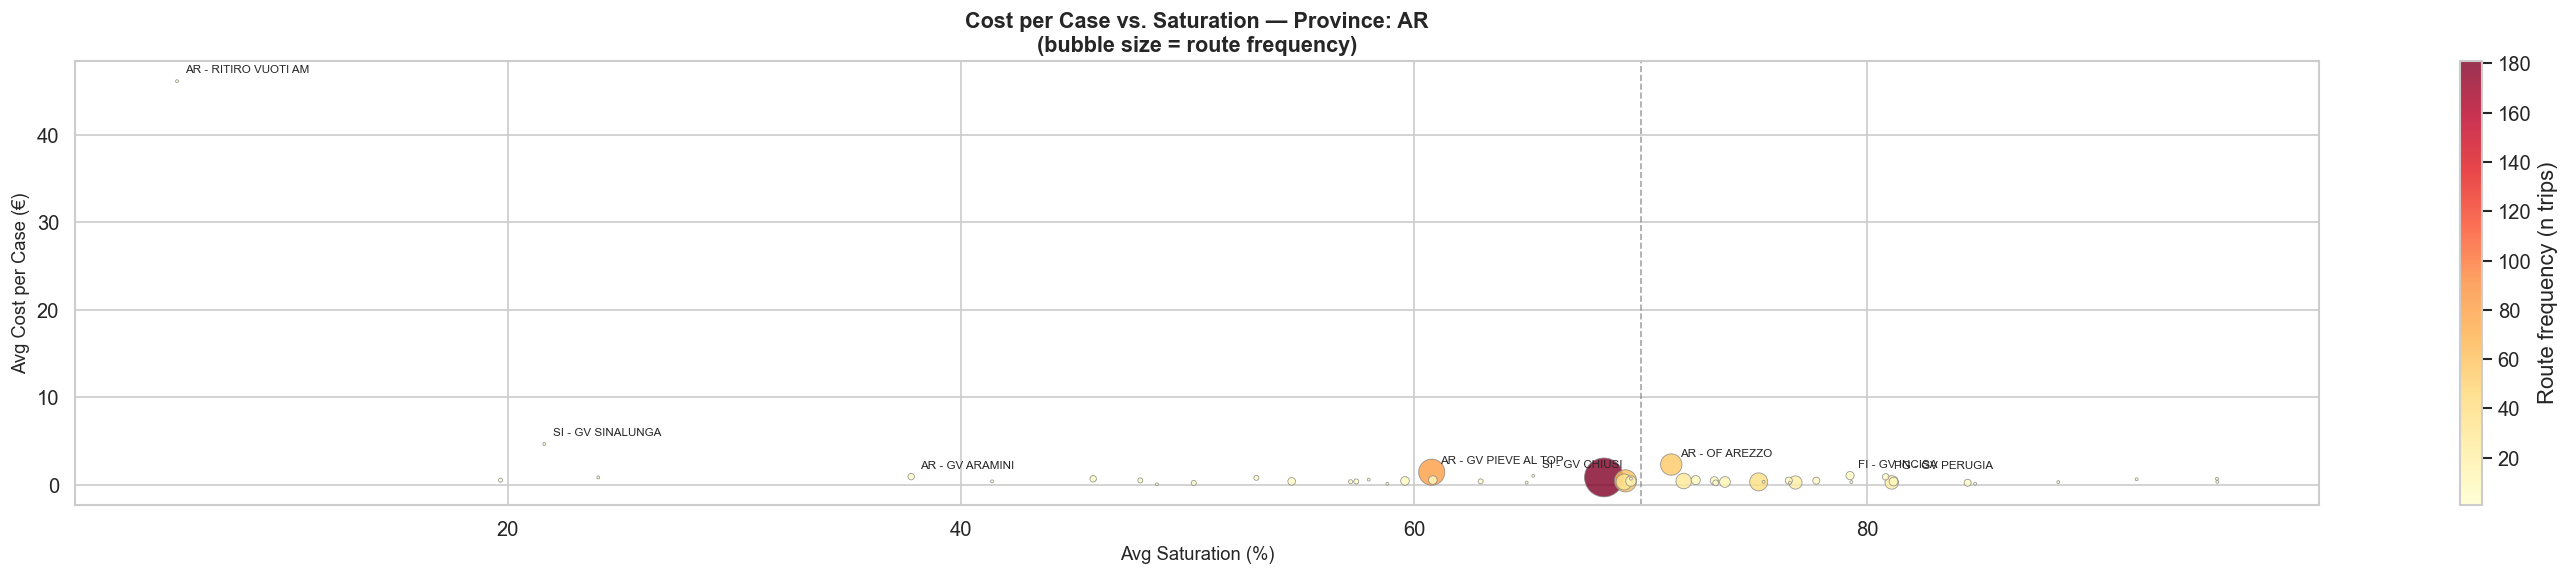

,Gita,Frequenza,Giorno_Principale,Provincia,Tariffa_AVG,KM_AVG,Costo_Viaggio_AVG,Colli_AVG,Costo_per_Collo_AVG,Colli_KM_AVG,Saturazione_AVG
0,AR - GV AREZZO,181,Giovedì,AR,1.07,153.21,161.98,792.98,0.87,5.55,68.38
1,AR - GV PIEVE AL TOPPO,82,Mercoledì,AR,1.16,136.00,157.25,871.29,1.47,6.57,60.78
2,AR - GV CASENTINO,59,Lunedì,AR,1.12,244.33,271.77,979.95,0.48,4.22,69.33
3,AR - OF AREZZO,55,Mercoledì,AR,1.05,227.60,239.64,672.89,2.34,3.03,71.35
4,FI - OF VALDARNO,39,Giovedì,AR,1.07,193.18,207.75,716.49,0.36,3.71,75.21
5,FI - GV VALDARNO,31,Giovedì,AR,1.10,120.71,133.39,827.71,0.35,7.14,69.27
6,AR - OF VALDARNO,29,Lunedì,AR,1.04,193.34,201.03,506.38,0.46,2.63,71.90
7,AR - ABB CASENTINO,22,Lunedì,AR,1.11,231.00,265.44,1085.55,0.30,5.19,81.08
8,AR - GV SAN SEPOLCRO,21,Giovedì,AR,1.18,248.37,289.74,1332.71,0.29,5.61,76.83
9,AR - OF CASENTINO,14,Martedì,AR,1.21,286.64,345.76,1063.50,0.35,3.76,73.72


In [6]:
# ── Visualize all routes for province AR ──────────────────────
kpi_ar = VisualGite('AR')

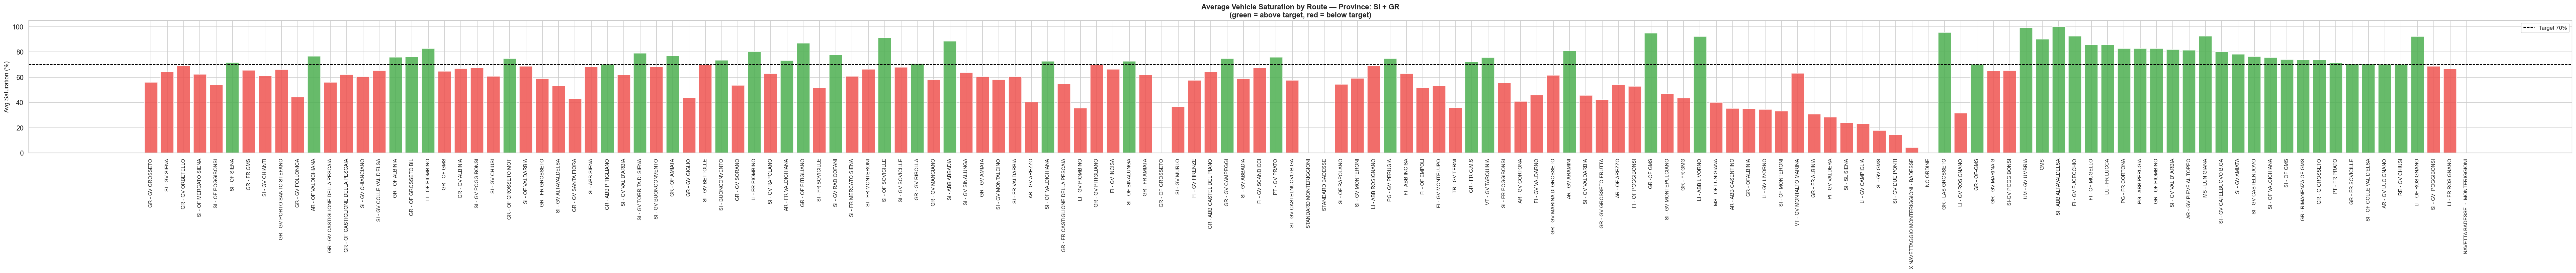

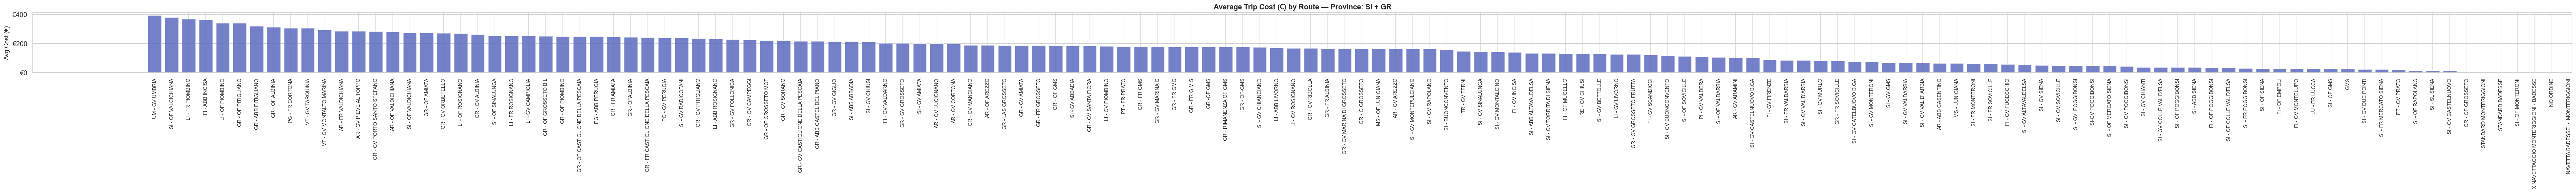

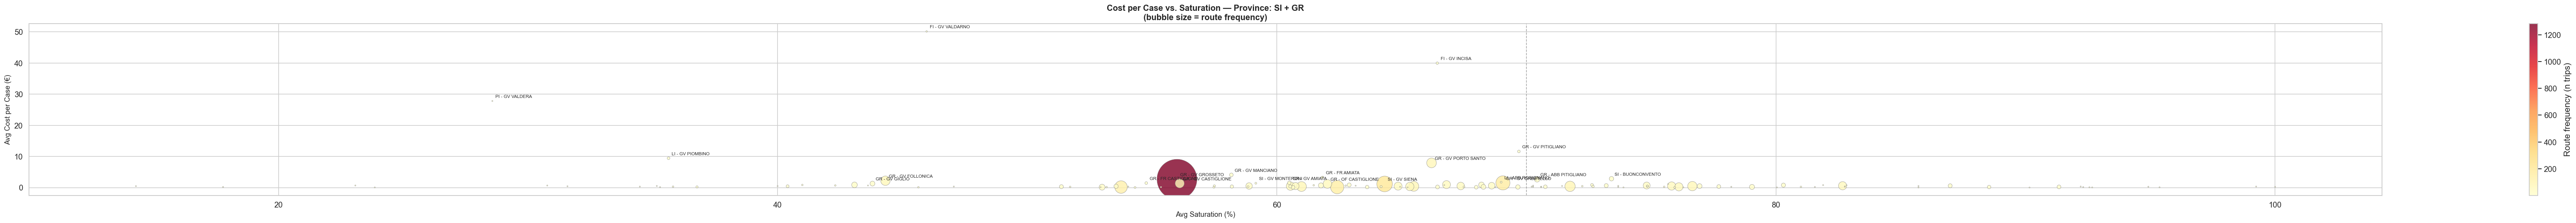

,Gita,Frequenza,Giorno_Principale,Provincia,Tariffa_AVG,KM_AVG,Costo_Viaggio_AVG,Colli_AVG,Costo_per_Collo_AVG,Colli_KM_AVG,Saturazione_AVG
0,GR - GV GROSSETO,1284,Venerdì,GR,1.02,197.40,201.58,602.75,2.67,3.25,56.00
1,SI - GV SIENA,196,Martedì,SI,1.12,45.96,51.85,931.41,1.17,34.37,64.32
2,GR - GV ORBETELLO,160,Martedì,GR,1.06,254.48,270.41,1107.32,1.51,4.33,69.06
3,SI - OF MERCATO SIENA,143,Sabato,SI,1.01,45.65,46.16,365.76,0.15,8.25,62.42
4,SI - OF POGGIBONSI,126,Sabato,SI,1.01,36.31,36.81,311.12,0.17,8.66,53.76
...,...,...,...,...,...,...,...,...,...,...,...
138,RE - GV CHIUSI,1,Martedì,SI,1.05,125.00,131.00,210.00,0.62,1.68,70.27
139,LI - OF ROSIGNANO,1,Martedì,SI,1.05,257.00,269.34,786.00,0.34,3.06,92.21
140,SI - GV POGGIBONSI,1,Venerdì,SI,1.05,47.00,49.26,314.00,0.16,6.68,68.76
141,LI - FR ROSIGNANO,1,Mercoledì,SI,1.05,241.00,252.57,314.00,0.80,1.30,66.71


In [7]:
# ── Compare two provinces side by side ────────────────────────
kpi_si_gr = VisualGite('SI', 'GR')

### Weekly schedule view — `GiteWeek()`

Shows how routes are distributed across the week for a province. Two charts: route count + avg saturation per day, and a saturation heatmap (day × route). Ideal for identifying underloaded days or scheduling imbalances.

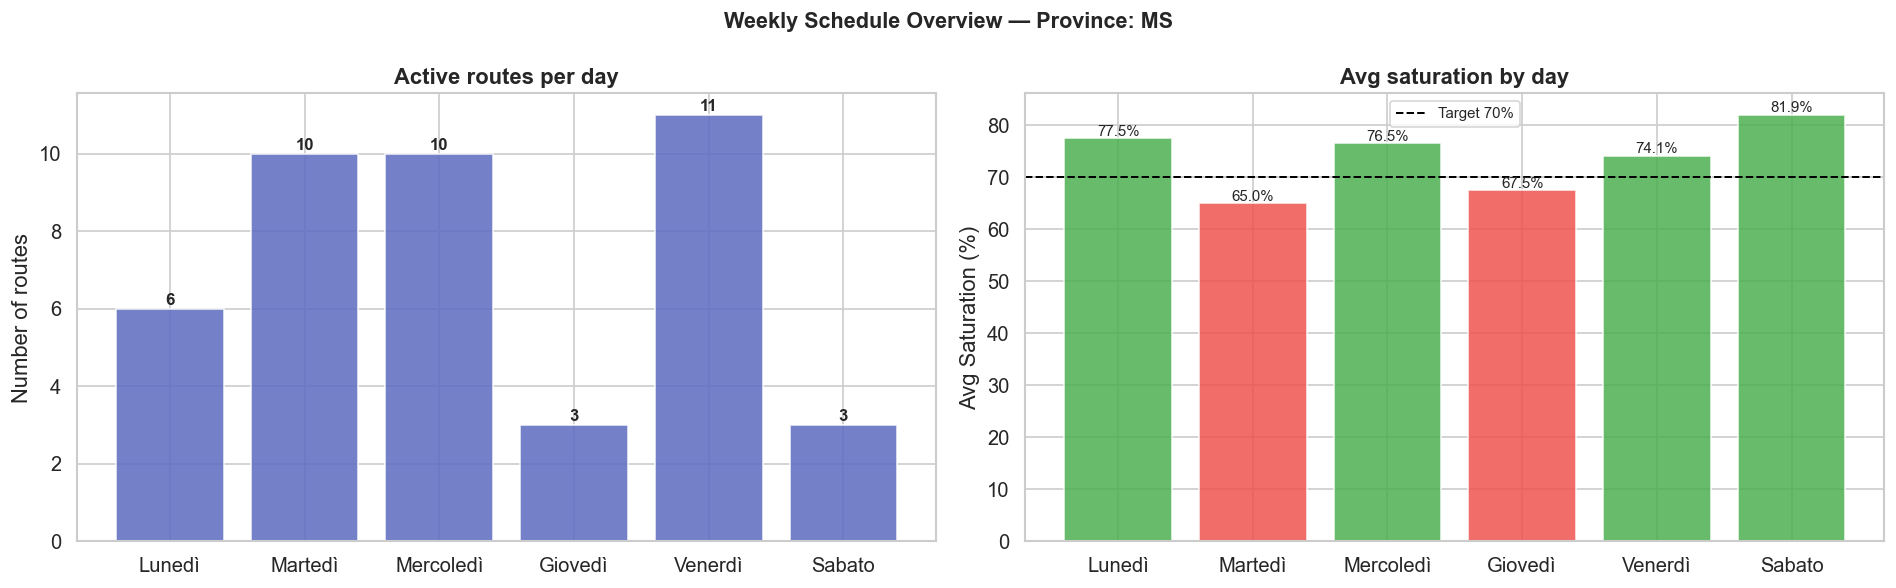

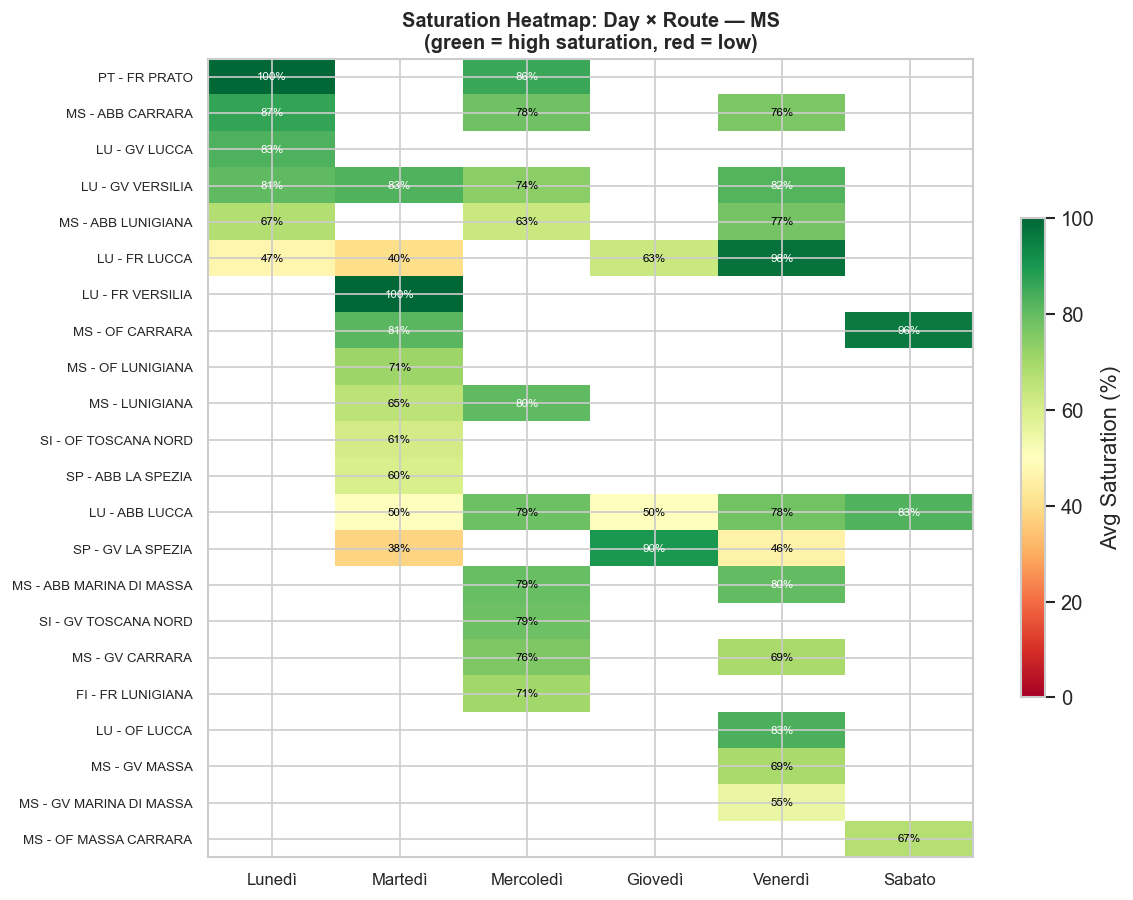

,Giorno,Gita,N_Viaggi,KM_AVG,Costo_Viaggio_AVG,Colli_AVG,Costo_per_Collo_AVG,Saturazione_AVG
26,Giovedì,SP - GV LA SPEZIA,4,537.00,533.24,779.50,0.70,89.50
27,Giovedì,LU - FR LUCCA,1,363.00,380.42,366.00,1.04,62.90
28,Giovedì,LU - ABB LUCCA,1,363.00,380.42,302.00,1.26,50.00
1,Lunedì,PT - FR PRATO,1,472.00,468.70,332.00,1.41,100.00
0,Lunedì,MS - ABB CARRARA,15,395.10,428.96,912.10,0.60,86.60
4,Lunedì,LU - GV LUCCA,1,435.00,542.88,1280.00,0.42,83.10
3,Lunedì,LU - GV VERSILIA,4,363.00,393.51,639.50,0.62,80.70
2,Lunedì,MS - ABB LUNIGIANA,27,443.20,462.94,518.10,2.27,67.30
5,Lunedì,LU - FR LUCCA,1,437.00,433.94,234.00,1.85,47.10
6,Martedì,LU - FR VERSILIA,1,473.00,469.69,542.00,0.87,100.00



Province: MS | Days with routes: 6 | Unique routes: 22


In [8]:
# ── Weekly schedule for province MS ────────────────────────────────────────
week_ms = GiteWeek('MS')

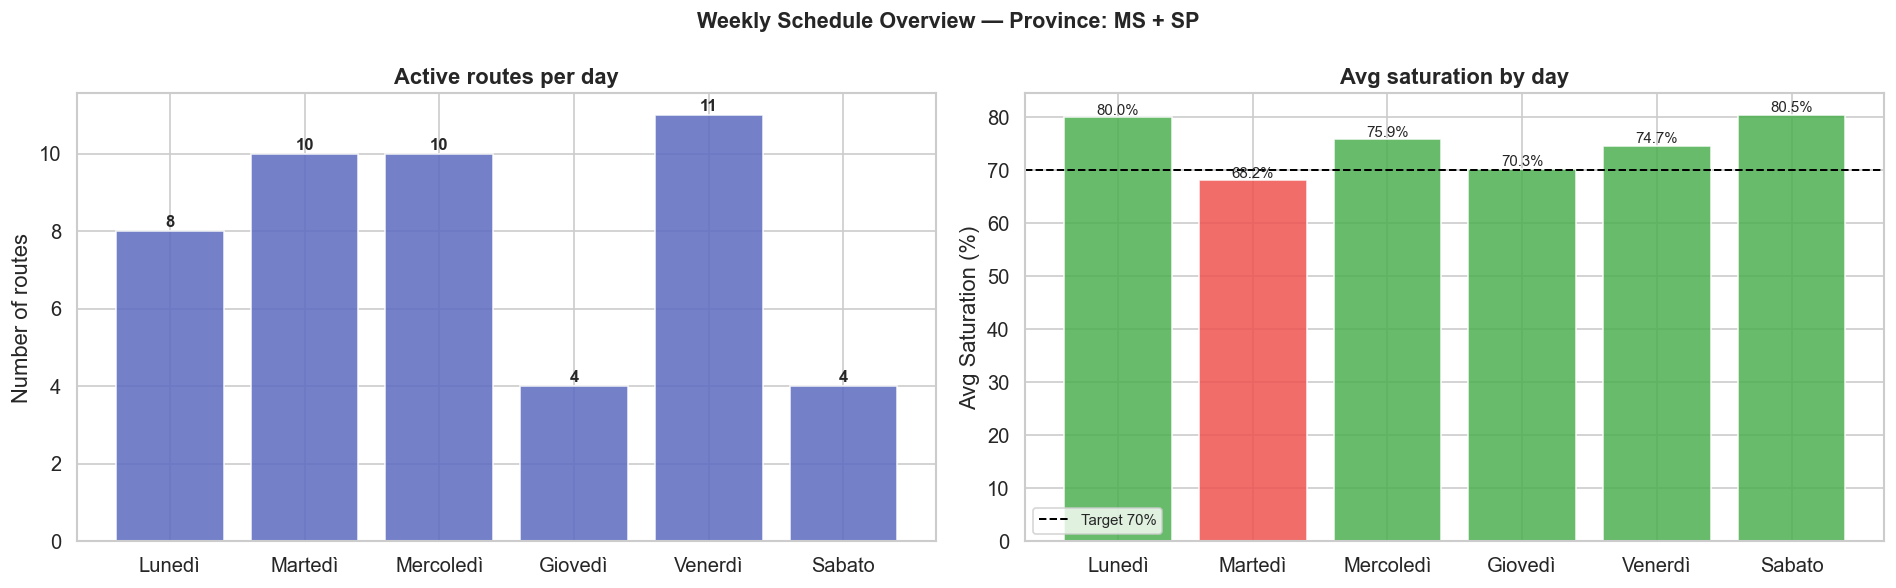

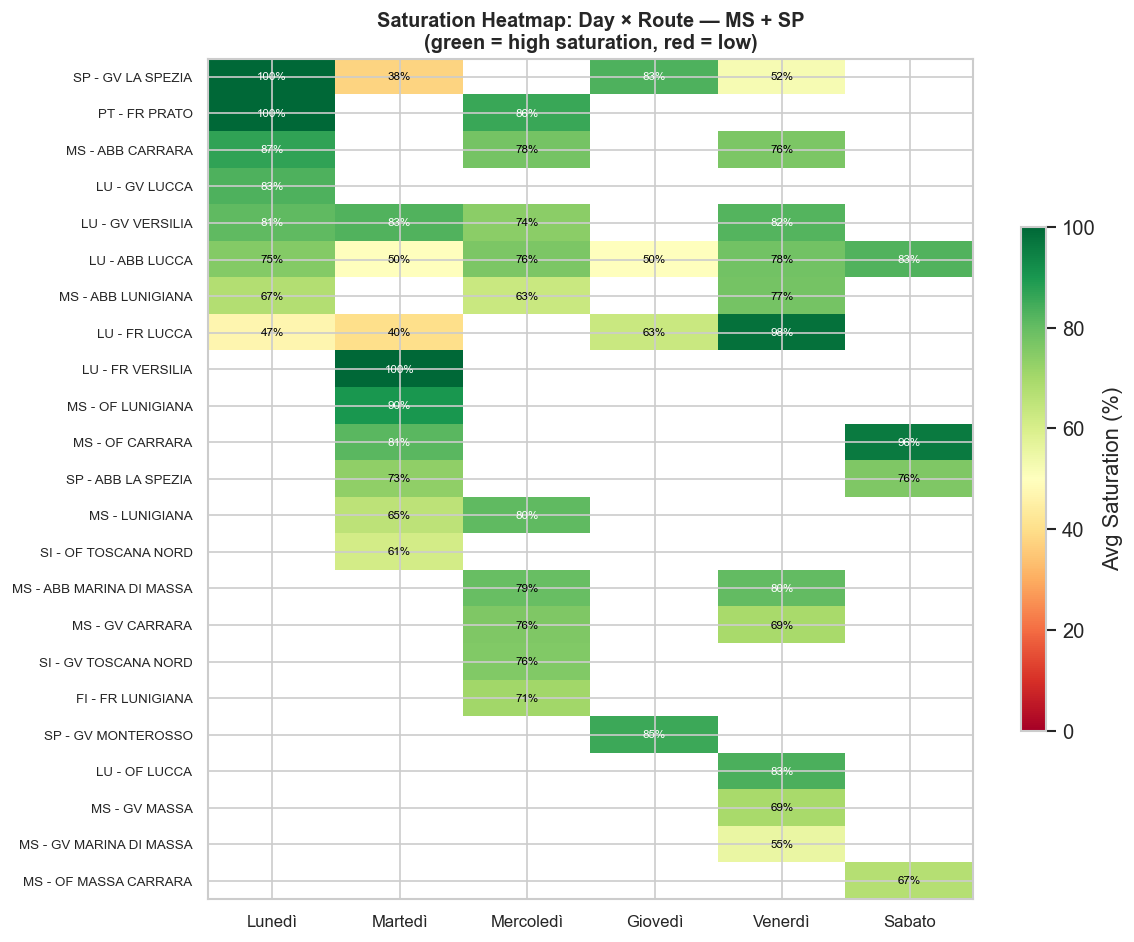

,Giorno,Gita,N_Viaggi,KM_AVG,Costo_Viaggio_AVG,Colli_AVG,Costo_per_Collo_AVG,Saturazione_AVG
29,Giovedì,SP - GV MONTEROSSO,4,496.50,493.03,587.20,1.02,85.30
28,Giovedì,SP - GV LA SPEZIA,10,500.40,511.34,607.20,0.85,83.00
30,Giovedì,LU - FR LUCCA,1,363.00,380.42,366.00,1.04,62.90
31,Giovedì,LU - ABB LUCCA,1,363.00,380.42,302.00,1.26,50.00
1,Lunedì,PT - FR PRATO,1,472.00,468.70,332.00,1.41,100.00
2,Lunedì,SP - GV LA SPEZIA,1,474.00,470.68,294.00,1.60,100.00
0,Lunedì,MS - ABB CARRARA,16,396.80,435.85,969.50,0.58,87.10
6,Lunedì,LU - GV LUCCA,1,435.00,542.88,1280.00,0.42,83.10
5,Lunedì,LU - GV VERSILIA,4,363.00,393.51,639.50,0.62,80.70
4,Lunedì,LU - ABB LUCCA,7,416.00,413.09,393.90,1.16,75.10



Province: MS + SP | Days with routes: 6 | Unique routes: 23


In [9]:
# ── Combined MS + SP weekly view ───────────────────────────────────────────
week_ms_sp = GiteWeek('MS', 'SP')

## 6. Case Study — Route Deep Dive: X - ORO DELLA TERRA

This route is a real-world example of a **structurally anomalous route** — a dedicated salumi (cured meats) delivery circuit operating on a fixed Mon/Wed/Fri schedule, served by a single carrier.

It is excluded from the general `VisualGite()` saturation analysis because its low saturation figures are **by design** (small-format deliveries, specialty product, fixed frequency contract) rather than an optimization opportunity.

This section shows what a dedicated per-route drill-down looks like, using the same SIGEP data source.

Route: X - ORO DELLA TERRA
Total trips: 55
Unique PDVs served: 55
Avg saturation: 62.6%
Avg trip cost: €1023.75



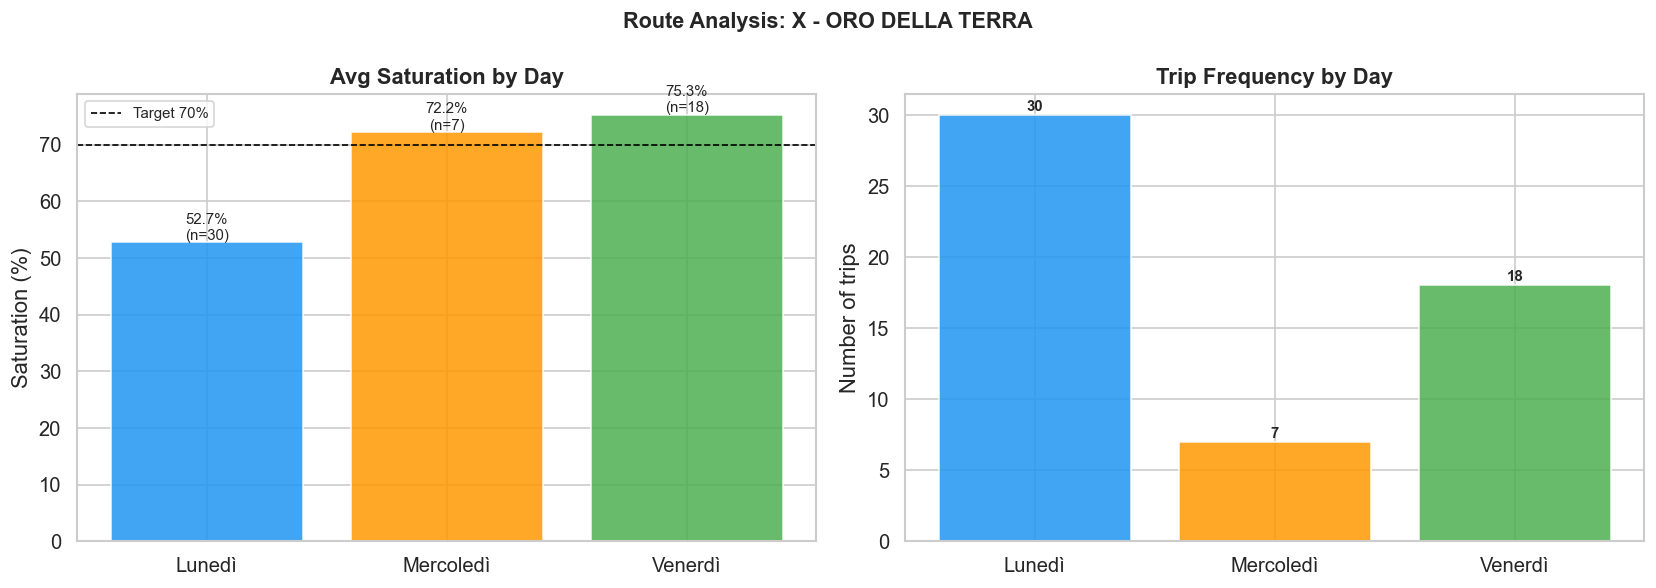

In [10]:
# ── Case Study: X - ORO DELLA TERRA ───────────────────────────────────────
# Fixed Mon/Wed/Fri specialty route — excluded from general saturation ranking
# because its structure is contractually defined, not a performance issue.

ROUTE_NAME   = 'X - ORO DELLA TERRA'
FIXED_DAYS   = ['Lunedì', 'Mercoledì', 'Venerdì']
_GIORNI_SHORT = {'Lunedì': 'LUN', 'Mercoledì': 'MER', 'Venerdì': 'VEN'}

route_data = data[data['VIAGGIO_GRP'] == ROUTE_NAME].copy()

if route_data.empty:
    print(f'[!] Route "{ROUTE_NAME}" not found in dataset.')
else:
    # ── Trip-level table for this route ───────────────────────────────
    route_trips = table[table['Gita'] == ROUTE_NAME].copy()

    print(f'Route: {ROUTE_NAME}')
    print(f'Total trips: {len(route_trips)}')
    print(f'Unique PDVs served: {route_data["PDV"].nunique()}')
    print(f'Avg saturation: {route_trips["Saturazione"].mean():.1f}%')
    print(f'Avg trip cost: €{route_trips["Costo_Viaggio"].mean():.2f}')
    print()

    # ── Plot 1: Saturation by delivery day ────────────────────────────
    day_stats = (route_trips[route_trips['Giorno'].isin(FIXED_DAYS)]
                 .groupby('Giorno')['Saturazione']
                 .agg(['mean', 'count'])
                 .reindex(FIXED_DAYS)
                 .reset_index())
    day_stats.columns = ['Giorno', 'Saturazione_AVG', 'N_Trips']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Route Analysis: {ROUTE_NAME}', fontsize=13, fontweight='bold')

    axes[0].bar(day_stats['Giorno'], day_stats['Saturazione_AVG'],
                color=['#2196F3', '#FF9800', '#4CAF50'], alpha=0.85, edgecolor='white')
    axes[0].axhline(70, color='black', linestyle='--', linewidth=1, label='Target 70%')
    axes[0].set_title('Avg Saturation by Day', fontweight='bold')
    axes[0].set_ylabel('Saturation (%)')
    axes[0].legend(fontsize=9)
    for i, (_, row) in enumerate(day_stats.iterrows()):
        axes[0].text(i, row['Saturazione_AVG'] + 0.5,
                     f"{row['Saturazione_AVG']:.1f}%\n(n={row['N_Trips']})",
                     ha='center', fontsize=9)

    # ── Plot 2: Trip frequency by day ─────────────────────────────────
    axes[1].bar(day_stats['Giorno'], day_stats['N_Trips'],
                color=['#2196F3', '#FF9800', '#4CAF50'], alpha=0.85, edgecolor='white')
    axes[1].set_title('Trip Frequency by Day', fontweight='bold')
    axes[1].set_ylabel('Number of trips')
    for i, (_, row) in enumerate(day_stats.iterrows()):
        axes[1].text(i, row['N_Trips'] + 0.3, str(int(row['N_Trips'])),
                     ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(PATH_PYTHON + 'casestudy_orodellaterra_days.png', bbox_inches='tight', dpi=150)
    plt.show()

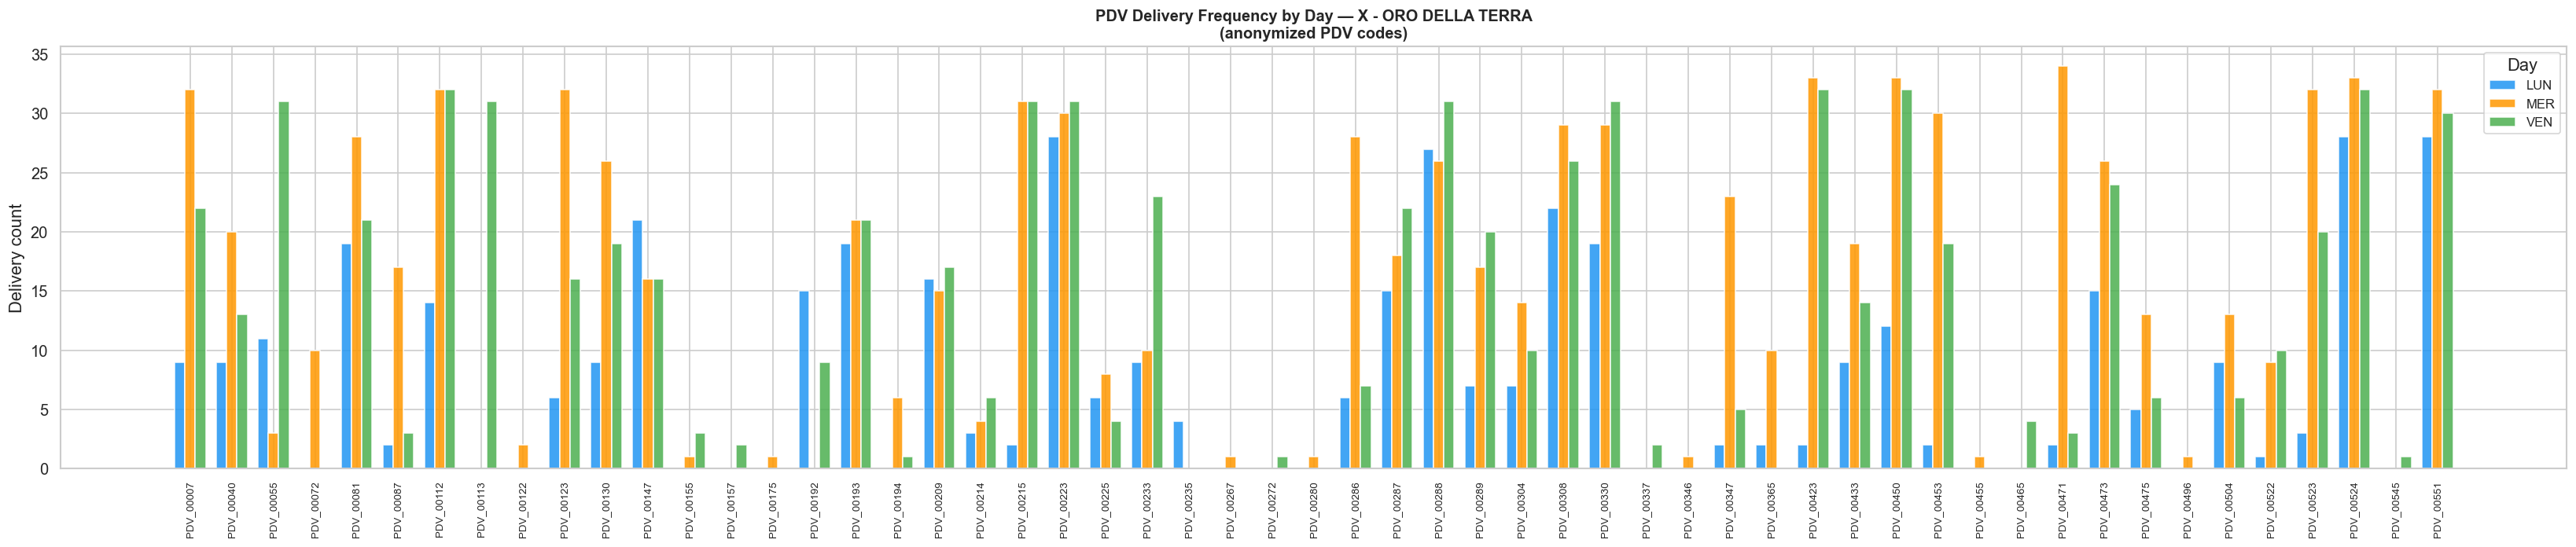

Active PDVs on route: 55


In [11]:
# ── PDV delivery frequency by day (grouped barplot) ───────────────────────
if not route_data.empty:
    pdv_list = route_data['PDV_ID'].dropna().unique()

    records = []
    for pdv in pdv_list:
        for day in FIXED_DAYS:
            freq = route_data.loc[
                (route_data['PDV_ID'] == pdv) & (route_data['GIORNO_WK'] == day),
                'N_VIAGGIO'
            ].nunique()
            records.append({'PDV': pdv, 'Giorno': _GIORNI_SHORT[day], 'Frequenza': freq})

    freq_df = pd.DataFrame(records)
    # Keep only PDVs with at least one delivery
    active_pdv = freq_df.groupby('PDV')['Frequenza'].sum()
    active_pdv = active_pdv[active_pdv > 0].index
    freq_df = freq_df[freq_df['PDV'].isin(active_pdv)]

    n = len(active_pdv)
    fig, ax = plt.subplots(figsize=(max(14, n * 0.5), 6))
    x = range(n)
    pdvs = list(active_pdv)
    width = 0.25
    colors = ['#2196F3', '#FF9800', '#4CAF50']

    for i, (day_short, color) in enumerate(zip(['LUN', 'MER', 'VEN'], colors)):
        vals = [freq_df.loc[(freq_df['PDV'] == p) & (freq_df['Giorno'] == day_short),
                            'Frequenza'].values[0] for p in pdvs]
        ax.bar([xi + i * width for xi in x], vals, width=width,
               label=day_short, color=color, alpha=0.85, edgecolor='white')

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(pdvs, rotation=90, fontsize=8)
    ax.set_title(f'PDV Delivery Frequency by Day — {ROUTE_NAME}\n(anonymized PDV codes)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Delivery count')
    ax.legend(title='Day', fontsize=10)
    plt.tight_layout()
    plt.savefig(PATH_PYTHON + 'casestudy_orodellaterra_pdv.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f'Active PDVs on route: {len(active_pdv)}')

In [12]:
# ── Day × PDV frequency matrix (pivot table) ──────────────────────────────
if not route_data.empty:
    pivot = freq_df.pivot(index='PDV', columns='Giorno', values='Frequenza')[['LUN', 'MER', 'VEN']]
    pivot['TOTALE'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('TOTALE', ascending=False)

    print(f'PDV × Day frequency matrix — {ROUTE_NAME}')
    print(f'(sorted by total deliveries)')
    display(pivot)

    # Export to Excel
    pivot.to_excel(PATH_EXCEL + 'OroDellaTerra_FrequenzaPDV.xlsx')
    print('\nExported → OroDellaTerra_FrequenzaPDV.xlsx')

PDV × Day frequency matrix — X - ORO DELLA TERRA
(sorted by total deliveries)


Giorno,LUN,MER,VEN,TOTALE
PDV,,,,
PDV_00524,28,33,32,93
PDV_00551,28,32,30,90
PDV_00223,28,30,31,89
PDV_00288,27,26,31,84
PDV_00330,19,29,31,79
PDV_00112,14,32,32,78
PDV_00450,12,33,32,77
PDV_00308,22,29,26,77
PDV_00081,19,28,21,68



Exported → OroDellaTerra_FrequenzaPDV.xlsx


## 7. Overall KPI Summary

In [13]:
SAT_TARGET = 70

summary = (
    table_clean
    .groupby('Provincia', sort=True)
    .agg(
        N_Trips         =('Viaggio',       'count'),
        N_Routes        =('Gita',          'nunique'),
        Sat_AVG         =('Saturazione',   'mean'),
        Sat_below_target=('Saturazione',   lambda x: (x < SAT_TARGET).sum()),
        Cost_AVG        =('Costo_Viaggio', 'mean'),
        CostPerCase_AVG =('Costo_per_Collo', lambda x: x.replace([np.inf,-np.inf], np.nan).mean()),
        KM_AVG          =('KM',            'mean'),
    )
    .round(2)
    .reset_index()
)
summary['%_below_target'] = (summary['Sat_below_target'] / summary['N_Trips'] * 100).round(1)

print('=' * 65)
print('  LOGISTICS KPI SUMMARY — ALL PROVINCES')
print('=' * 65)

# Use .style only if jinja2 is available, otherwise plain display
try:
    import jinja2
    display(
        summary.style
        .background_gradient(subset=['Sat_AVG'],         cmap='RdYlGn')
        .background_gradient(subset=['CostPerCase_AVG'], cmap='RdYlGn_r')
        .format({
            'Sat_AVG':          '{:.1f}%',
            'Cost_AVG':         '€{:.2f}',
            'CostPerCase_AVG':  '€{:.2f}',
            'KM_AVG':           '{:.0f} km',
            '%_below_target':   '{:.1f}%',
        })
    )
except ImportError:
    # jinja2 not installed — plain formatted display
    fmt = summary.copy()
    fmt['Sat_AVG']          = fmt['Sat_AVG'].map('{:.1f}%'.format)
    fmt['Cost_AVG']         = fmt['Cost_AVG'].map('€{:.2f}'.format)
    fmt['CostPerCase_AVG']  = fmt['CostPerCase_AVG'].map('€{:.2f}'.format)
    fmt['KM_AVG']           = fmt['KM_AVG'].map('{:.0f} km'.format)
    fmt['%_below_target']   = fmt['%_below_target'].map('{:.1f}%'.format)
    display(fmt)

# Identify top optimization opportunities
low_sat = table_clean[table_clean['Saturazione'] < SAT_TARGET]
print(f'\nRoutes below {SAT_TARGET}% saturation: {len(low_sat)} / {len(table_clean)} '
      f'({len(low_sat)/len(table_clean)*100:.1f}%)')
print(f'Estimated excess cost (low-sat trips): '
      f'€{low_sat["Costo_Viaggio"].sum():,.0f}')

  LOGISTICS KPI SUMMARY — ALL PROVINCES


,Provincia,N_Trips,N_Routes,Sat_AVG,Sat_below_target,Cost_AVG,CostPerCase_AVG,KM_AVG,%_below_target
0,AQ,10,3,83.9%,3,€760.03,€0.90,609 km,30.0%
1,AR,685,54,68.6%,292,€199.86,€0.93,185 km,42.6%
2,BO,8,1,68.8%,4,€309.51,€0.47,291 km,50.0%
3,FI,895,66,65.5%,452,€159.59,€0.87,154 km,50.5%
4,GR,2345,58,60.3%,1371,€221.59,€2.22,219 km,58.5%
5,LI,364,31,69.1%,176,€283.04,€2.02,287 km,48.4%
6,LU,274,19,75.0%,100,€352.87,€0.81,340 km,36.5%
7,MS,236,22,73.9%,78,€429.98,€2.19,409 km,33.1%
8,PG,317,29,72.7%,118,€336.82,€2.06,318 km,37.2%
9,PI,215,27,62.9%,113,€247.54,€1.27,224 km,52.6%



Routes below 70% saturation: 3727 / 7473 (49.9%)
Estimated excess cost (low-sat trips): €698,852


---
## Notes

**Vehicle rate table used:**

| Category | Rate (€/km) |
|---|---|
| Motrice 3 assi | 1.048 |
| Motrice 2 assi / Daily | 0.993 |
| Bilico / Bilichetto | 1.248 |

**Special routes excluded from saturation analysis:**  
Navettaggio, Transit Point, Vuoti, Taxi Merci — these have structural near-zero saturation and distort province-level averages.

**Bug fixed vs. original:**  
`Costo_per_Collo` and `Colli_KM` were producing `inf` when `Colli == 0` (navettaggio trips with no cases). Now returns `NaN` and is excluded from averages.

---
*Analysis built on anonymized SIGEP export data. Giuseppe Iaccarino — 2022/2026.*